In [1]:
import cafe

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

In [2]:
filename = "output/26.02.02-gastrulation_case_data/gastrulation.h5ad"
fadata = cafe.data.read_h5ad(filename)
global_model_name = "ref_coarse_projection"
# cafe.plot.plot_graph(fadata, model_name=global_model_name)
fadata

AnnData object with n_obs × n_vars = 89267 × 53801
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom', 'celltype_coarse', 'celltype_new', 'pseudotime'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'cafe', 'celltype_coarse_colors', 'celltype_colors', 'celltype_new_colors', 'id'
    obsm: 'X_pca', 'X_stavia', 'X_umap'
    layers: 'spliced', 'unspliced'

merge

In [3]:
def get_filename(milestone_name):
    return f".cafe/gastrulation_{milestone_name.lower()}/h5ad/gastrulation_{milestone_name.lower()}.h5ad"


replace_milestone_dict = {
    "Blast":{
        # "fadata_sub_filename": ".cafe/gastrulation_blast/h5ad/gastrulation_blast.h5ad",
        "fadata_sub_filename": get_filename("Blast"),
        "sub_model_name": "ref" # mannual
    },
    "Ectoderm": {
        "fadata_sub_filename": get_filename("Ectoderm"),
        "sub_model_name": "ref"
    },
    "Mesoderm": {
        "fadata_sub_filename": get_filename("Mesoderm"),
        "sub_model_name": "ref"
    },
    "Endoderm": {
        "fadata_sub_filename": get_filename("Endoderm"),
        "sub_model_name": "ref"
    },
    "Neural": {
        "fadata_sub_filename": get_filename("Neural"),
        "sub_model_name": "ref"
    },
    "Blood": {
        "fadata_sub_filename": get_filename("Blood"),
        "sub_model_name": "veloae"  # veloae method result
    },
}

In [4]:
fadata.trajectory_history_dict["merge"] = fadata.get_trajectory_dict(global_model_name) # iteratively merge trajectory to the same model
for replace_milestone, replace_info in replace_milestone_dict.items():
    fadata_sub = cafe.data.read_h5ad(replace_info["fadata_sub_filename"]) # read fadata_sub
    fadata_sub.load_trajectory_dict(replace_info["sub_model_name"]) # load trajectory dict
    fadata.merge_milestone_trajectory(
        fadata_sub=fadata_sub,
        replace_milestone=replace_milestone,
        model_name="merge",
        sub_model_name=replace_info["sub_model_name"],
        save_model_name="merge"
    )
    cafe.logger.info(f"Processed milestone: {replace_milestone}, fadata_sub shape: {fadata_sub.shape}, model_name: `{replace_info['sub_model_name']}`")

WARNING  |- The replace milestone 'Blast' has no predecessor edge                                                                                                                                       
INFO     |- Processed milestone: Blast, fadata_sub shape: (23186, 53801), model_name: `ref`                                                                                                             
INFO     |- Processed milestone: Ectoderm, fadata_sub shape: (9044, 53801), model_name: `ref`                                                                                                           
INFO     |- Processed milestone: Mesoderm, fadata_sub shape: (22245, 53801), model_name: `ref`                                                                                                          
INFO     |- Processed milestone: Endoderm, fadata_sub shape: (4004, 53801), model_name: `ref`                                                                                                       

WARNING  |- The number of colors(34) is greater than the number of colors in the 'Set3' palette(12), and the 'husl' palette selection is used.                                                          


array([[<Axes: title={'center': 'merge(celltype)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>]],
      dtype=object)

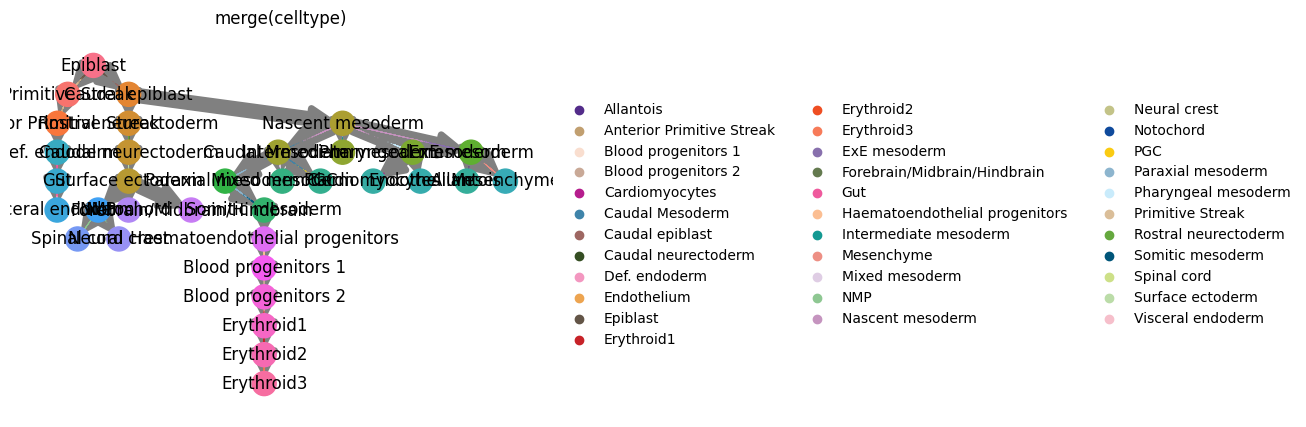

In [5]:
cafe.plot.plot_graph(fadata, model_name="merge")

In [6]:
fadata.write_trajectory_dict(model_name_list=["merge"])